# DUET Classification Notebook

Этот блокнот приведён в соответствие с текущей архитектурой DUET для **классификации временных рядов**:
- **TCM** сегментирует ряд на патчи, выделяет тренд/сезонность и маршрутизирует их по temporal-кластерам.
- **CCM** работает в частотной области, учит межканальные связи и разреживает маску.
- **Fusion** объединяет temporal-признаки и маску каналов, после чего **classification head** выдаёт logits классов.

Ниже используются параметры `K_t`, `K_c`, `d_c`, `top_k`, а также RevIN/InstanceNorm в соответствии с `architecture.md`.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/stocks/duet/duet_class")

from pipeline.config import DUETConfig
from pipeline import preprocess, train, evaluate, predict
from pipeline.prepare_and_check import FinancialTimeSeriesPreparer
from pipeline.wf_slicer import GlobalNormConfig, SplitConfig, WalkForwardWindowSlicerVec, WindowConfig
from duet.model import DUETModel
from torch.utils.data import DataLoader, TensorDataset
import torch
import joblib
import random

import numpy as np
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight


In [3]:
# Настройки
DATA_PATH = "/content/drive/MyDrive/stocks/Data/anomaly/anomaly_df_binance_BTCUSDT_futures_cufOff_1.5.joblib"
LABELS_PATH = "/content/drive/MyDrive/stocks/Data/anomaly/Dataset_2_7class_clear - Dataset_2_7class_clear.csv.csv"
device = "cuda" if torch.cuda.is_available() else "cpu"

config = DUETConfig(
    # =========================
    # Общие параметры
    # =========================
    timestamp_col = "timestamp",
    features = [
       'Open', 'High', 'Low', 'Close',
       'Volume',
    ],                           # Название колонок для обучения
    forecast = 'target',          # Название колонки с таргетом
    not_to_normalise = [],       # Название колонок, которые НЕ НАДО нормализовать
    scaler = 'NONE',         # Тип нормализации (STD, MINMAX, QUANT)
    predict_type = 'detect',     # Детекция "detect" или предикт "next" следующей свечи
    seq_len = 48,                # Длина входной последовательности
    num_classes = 7,             # кол-во классов
    patch_len = 24,               # Длина патча (TCM)
    stride = 12,                  # Шаг между патчами (TCM)
    moving_avg = 25,              # Размер окна скользящего сглаживания

    K_t = 2,                    # Кол-во временных кластеров (TCM)
    K_c = 4,                    # Кол-во кластеров каналов (CCM)
    d_c = 32,                   # Размерность embedding каналов (CCM)
    top_k = 2,                  # Кол-во связей при разреживании маски
    use_revin = True,           # Включить RevIN/InstanceNorm (если отключить, то нужно нормализовать данные отдельно)
    revin_affine = True,        # Использовать affine параметры в RevIN
    revin_eps = 1e-5,           # Эпсилон для стабильности RevIN

    # =========================
    # Параметры модели
    # =========================
    d_model = 64,               # Размерность скрытого пространства в attention
    d_ff = 256,                 # Размерность feedforward слоя
    n_heads = 4,                # Количество голов в multi-head attention
    e_layers = 2,               # Количество слоев в encoder (CCM)
    dropout = 0.2,            # Dropout во всех слоях attention
    fc_dropout = 0.2,         # Dropout в выходном head слое
    activation = "relu",        # Активационная функция (relu, gelu, elu)
    num_experts = 4,            # Число экспертов (в Router, если используется)
    report_freq = 10,            # Частота появления confusion matrix

    # =========================
    # Режимы обработки
    # =========================
    CI = True,                 # Channel-Independent режим (если False — shared weights)
    use_router = True,          # Включить распределительный роутер
    timeenc = 1,                # Использовать time encoding (0 = без, 1 = sin/cos и т.п.)

    # =========================
    # Настройки обучения
    # =========================
    batch_size=32,          # можно немного увеличить при хорошем GPU
    epochs=300,             # больше эпох для более тонкой настройки
    learning_rate=1e-4,     # стандартный LR для Adam
    weight_decay=1e-5,
    patience=100,            # early stopping не слишком строгий

    # =========================
    # Прочее
    # =========================
    checkpoint_best = '/content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt',       # Путь для сохранения лучших по val_accuracy весов
    checkpoint_final = '/content/drive/MyDrive/stocks/duet/duet_class/weights/final_weights_002.pt',      # Путь для сохранения финальных весов
    seed = 33,                  # Фиксированное зерно генератора случайных чисел
    verbose = True,            # Печать хода обучения
)

"""
Устанавливает seed для numpy, random, torch (вкл. CUDA).
Гарантирует воспроизводимость.
"""

random.seed(config.seed)
np.random.seed(config.seed)
torch.manual_seed(config.seed)
torch.cuda.manual_seed_all(config.seed)

## Варианты запуска обучения (наборы конфигураций)

Ниже — типовые варианты запуска, которые отражают логику обучения DUET: end-to-end обучение **TCM → CCM → Fusion → Head** с кросс-энтропией. Для каждого варианта меняются только ключевые параметры архитектуры и кластеризации, остальные поля берутся из базовой конфигурации.

**1) Базовый режим (баланс точности и стабильности):**
```python
DUETConfig(
    K_t=2, K_c=4, d_c=32, top_k=2,
    use_router=True, use_revin=True,
    d_model=64, d_ff=128, e_layers=2,
)
```

**2) Больше временных режимов (сложная динамика):**
```python
DUETConfig(
    K_t=4, patch_len=12, stride=6,
    use_router=True, num_experts=6,
    d_model=96, d_ff=256,
)
```

**3) Усиленная кластеризация каналов (много каналов/шумные связи):**
```python
DUETConfig(
    K_c=6, d_c=48, top_k=3,
    e_layers=3, dropout=0.15,
)
```

**4) Ablation без temporal-router (проверка вклада маршрутизации):**
```python
DUETConfig(
    use_router=False, K_t=1,
    d_model=64, d_ff=128,
)
```

Для запуска достаточно заменить поля в блоке `config = DUETConfig(...)` ниже или создать отдельные конфиги и прогнать обучение в цикле.


In [4]:
# @title Загрузка данных

df = joblib.load(DATA_PATH)
labels = pd.read_csv(LABELS_PATH)

data_preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col="timestamp",
    drop_warmup=True,
)
labels_preparer = FinancialTimeSeriesPreparer(
    tz="UTC",
    timestamp_col="Time_close",
    drop_warmup=True,
)

df, _ = data_preparer.prepare(df, ensure_ohlcv=True, from_date="2023-01-01", to_date="2024-01-30")
labels, _ = labels_preparer.prepare(labels, ensure_ohlcv=False, from_date="2022-01-01", to_date="2025-01-30")

labels.index = labels.index.round("1min")   # до ближайшей минуты
labels

,Unnamed: 0,Time_close,target,gaps,nan_filled,candle_error
datetime,,,,,,
2023-01-01 18:12:00+00:00,0.0,1.672597e+12,3.0,0,0,0
2023-01-01 18:13:00+00:00,0.0,1.672597e+12,NaN,1,1,0
2023-01-01 18:14:00+00:00,0.0,1.672597e+12,NaN,1,1,0
2023-01-01 18:15:00+00:00,0.0,1.672597e+12,NaN,1,1,0
2023-01-01 18:16:00+00:00,0.0,1.672597e+12,NaN,1,1,0


In [5]:
df['target'] = labels['target']
df.fillna({'target':-1}, inplace=True)
df['target'].value_counts()

,count
target,
-1.0,565351
1.0,825
3.0,629
0.0,173
2.0,166
4.0,136
5.0,50
6.0,30


In [6]:
from pipeline.timefeatures import time_features_from_index

time_features = time_features_from_index(df.index, timeenc=config.timeenc)
time_feature_names = [f"timeenc_{i}" for i in range(time_features.shape[1])]
df[time_feature_names] = time_features
config.features = config.features + time_feature_names

print(f"Config features: {config.features}")

df.head()

Config features: ['Open', 'High', 'Low', 'Close', 'Volume', 'timeenc_0', 'timeenc_1', 'timeenc_2', 'timeenc_3', 'timeenc_4', 'timeenc_5', 'timeenc_6', 'timeenc_7', 'timeenc_8', 'timeenc_9']


,timestamp,Open,High,Low,Close,Volume,Quote_asset_volume,Number_of_trades,Taker_buy_base_asset_volume,Taker_buy_quote_asset_volume,...,timeenc_0,timeenc_1,timeenc_2,timeenc_3,timeenc_4,timeenc_5,timeenc_6,timeenc_7,timeenc_8,timeenc_9
datetime,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00+00:00,1672531200000,16537.5,16538.0,16534.3,16538.0,170.576,2.820697e+06,946,103.782,1.716165e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.000000,1.000000
2023-01-01 00:01:00+00:00,1672531260000,16538.0,16538.0,16534.9,16534.9,44.287,7.323633e+05,570,19.098,3.158178e+05,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.104528,0.994522
2023-01-01 00:02:00+00:00,1672531320000,16534.9,16535.0,16531.3,16531.4,100.228,1.657072e+06,456,21.026,3.476265e+05,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.207912,0.978148
2023-01-01 00:03:00+00:00,1672531380000,16531.4,16531.4,16526.6,16526.9,317.879,5.254048e+06,980,79.937,1.321185e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.309017,0.951057
2023-01-01 00:04:00+00:00,1672531440000,16527.0,16529.3,16523.0,16529.2,211.281,3.491635e+06,1113,79.049,1.306280e+06,...,0.5,0.866025,0.201299,0.97953,-0.781832,0.62349,0.0,1.0,0.406737,0.913545


In [7]:
# --- 1. Предобработка данных ---

split = SplitConfig(
    n_folds=1,
    mode="expanding",
    ratios=(0.70, 0.299, 0.001),
    step_size=None,
    gap=0,
    sliding_train_size=None,
)

if config.predict_type.upper() == "DETECT":
    y_end_offset = 0
elif config.predict_type.upper() == "NEXT":
    y_end_offset = 1
else:
    raise ValueError("config.predict_type должен быть 'DETECT' или 'NEXT'")

window = WindowConfig(
    x_window=config.seq_len,
    x_end_offset=0,
    y_window=1,
    y_end_offset=y_end_offset,
    allow_left_context_for_x=False,
)

scaler_map = {"STD": "standard", "MINMAX": "minmax", "QUANT": "quantile", "NONE": "none"}
global_norm = GlobalNormConfig(scaler=scaler_map.get(config.scaler.upper(), "none"))

slicer = WalkForwardWindowSlicerVec(
    split=split,
    window=window,
    global_norm=global_norm,
    no_norm_cols=config.not_to_normalise,
    eps=1e-12,
    drop_incomplete_last_fold=True,
)

out = slicer.split_and_window(
    X=df[config.features],
    y=df[config.forecast],
    aux=df[['gaps', 'nan_filled', 'candle_error']]
)
fold0 = out["fold_0"]

x_train = fold0["train"]["X"]
y_train = fold0["train"]["y"][:, 0, 0].astype(int)
x_val = fold0["val"]["X"]
y_val = fold0["val"]["y"][:, 0, 0].astype(int)

x_test = fold0["test"]["X"]
y_test = fold0["test"]["y"][:, 0, 0].astype(int)

print(f"Train shape: {x_train.shape, y_train.shape}")
print(f"Val shape: {x_val.shape, y_val.shape}")
print(f"Test shape: {x_test.shape, y_test.shape}")


Train shape: ((397105, 48, 15), (397105,))
Val shape: ((169593, 48, 15), (169593,))
Test shape: ((521, 48, 15), (521,))


In [8]:

# Балансируем (если не нужно, то закомментировать)
x_train, y_train = preprocess.balance_windows(x_train, y_train, max_ratio=100, exclude_labels=-1)
x_val, y_val = preprocess.balance_windows(x_val, y_val, max_ratio=100, exclude_labels=-1)
# x_test, y_test = preprocess.balance_windows(x_test, y_test, max_ratio=100, exclude_labels=-1)

# Проверяем балансировку
unique, counts = np.unique(y_train, return_counts=True)
print("Классы после балансировки в трэйне:")
for k,v in zip(unique, counts):
  print(f"Class {k}: {v}")

unique, counts = np.unique(y_val, return_counts=True)
print("Классы после балансировки в трэйне:")
for k,v in zip(unique, counts):
  print(f"Class {k}: {v}")

# --- 3. Подсчет весов классов ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print(f"Распределение весов между класcами {class_weights}")



Балансировка: min=23, max=673, max_ratio=100.0 -> cap=2300
Балансировка: min=7, max=152, max_ratio=100.0 -> cap=700
Классы после балансировки в трэйне:
Class 0: 130
Class 1: 673
Class 2: 148
Class 3: 487
Class 4: 123
Class 5: 43
Class 6: 23
Классы после балансировки в трэйне:
Class 0: 43
Class 1: 152
Class 2: 18
Class 3: 142
Class 4: 13
Class 5: 7
Class 6: 7
Распределение весов между класcами tensor([ 1.7879,  0.3454,  1.5705,  0.4773,  1.8897,  5.4053, 10.1056],
       device='cuda:0')


[1/300] Train Loss: 1.9505 | Train Acc: 0.0916 | Val Loss: 1.8931 | Val Acc: 0.0833 | Val Macro F1: 0.0770 | Val PR AUC: 0.2907
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[2/300] Train Loss: 1.8492 | Train Acc: 0.1784 | Val Loss: 1.8043 | Val Acc: 0.1540 | Val Macro F1: 0.1277 | Val PR AUC: 0.3473
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[3/300] Train Loss: 1.7332 | Train Acc: 0.2303 | Val Loss: 1.7065 | Val Acc: 0.1698 | Val Macro F1: 0.1349 | Val PR AUC: 0.3862
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[4/300] Train Loss: 1.6179 | Train Acc: 0.2834 | Val Loss: 1.6148 | Val Acc: 0.2405 | Val Macro F1: 0.1766 | Val PR AUC: 0.3997
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[5/300] Train Loss: 1.5457 | Train Acc: 0.3390 | Val Loss: 1.5472 | Val Acc: 0.3059 | Val Macro F1: 0.2180 | Val PR AUC: 0.4136
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[6/300] Train Loss: 1.4972 | Train Acc: 0.3759 | Val Loss: 1.5027 | Val Acc: 0.3766 | Val Macro F1: 0.2590 | Val PR AUC: 0.4310
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[7/300] Train Loss: 1.4377 | Train Acc: 0.4306 | Val Loss: 1.4602 | Val Acc: 0.4922 | Val Macro F1: 0.3154 | Val PR AUC: 0.4416
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[8/300] Train Loss: 1.4013 | Train Acc: 0.4781 | Val Loss: 1.4297 | Val Acc: 0.5500 | Val Macro F1: 0.3417 | Val PR AUC: 0.4521
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[9/300] Train Loss: 1.3639 | Train Acc: 0.5082 | Val Loss: 1.4016 | Val Acc: 0.5264 | Val Macro F1: 0.3322 | Val PR AUC: 0.4571
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[10/300] Train Loss: 1.3578 | Train Acc: 0.5303 | Val Loss: 1.3733 | Val Acc: 0.5686 | Val Macro F1: 0.3561 | Val PR AUC: 0.4785


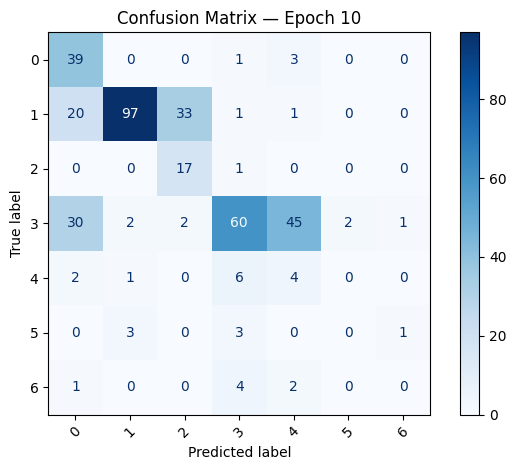

Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[11/300] Train Loss: 1.2980 | Train Acc: 0.5442 | Val Loss: 1.3530 | Val Acc: 0.5658 | Val Macro F1: 0.3578 | Val PR AUC: 0.4827
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[12/300] Train Loss: 1.2910 | Train Acc: 0.5652 | Val Loss: 1.3293 | Val Acc: 0.5608 | Val Macro F1: 0.3525 | Val PR AUC: 0.4889
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[13/300] Train Loss: 1.2556 | Train Acc: 0.5506 | Val Loss: 1.3069 | Val Acc: 0.5714 | Val Macro F1: 0.3537 | Val PR AUC: 0.4911
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[14/300] Train Loss: 1.2491 | Train Acc: 0.5711 | Val Loss: 1.2960 | Val Acc: 0.5741 | Val Macro F1: 0.3681 | Val PR AUC: 0.5009
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


...

[16/300] Train Loss: 1.2180 | Train Acc: 0.5627 | Val Loss: 1.2457 | Val Acc: 0.5899 | Val Macro F1: 0.3781 | Val PR AUC: 0.5084
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[17/300] Train Loss: 1.1958 | Train Acc: 0.5850 | Val Loss: 1.2468 | Val Acc: 0.5528 | Val Macro F1: 0.3630 | Val PR AUC: 0.5146


[18/300] Train Loss: 1.1933 | Train Acc: 0.5808 | Val Loss: 1.2329 | Val Acc: 0.5554 | Val Macro F1: 0.3669 | Val PR AUC: 0.5184
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[19/300] Train Loss: 1.1653 | Train Acc: 0.5795 | Val Loss: 1.2228 | Val Acc: 0.5632 | Val Macro F1: 0.3695 | Val PR AUC: 0.5204
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[20/300] Train Loss: 1.1383 | Train Acc: 0.5633 | Val Loss: 1.2185 | Val Acc: 0.5658 | Val Macro F1: 0.3763 | Val PR AUC: 0.5230


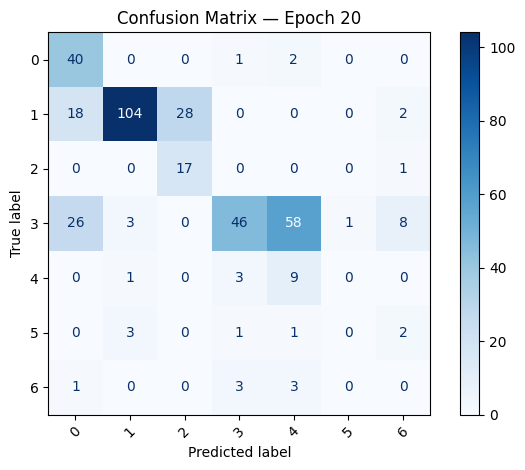

Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[21/300] Train Loss: 1.1442 | Train Acc: 0.5768 | Val Loss: 1.2075 | Val Acc: 0.5528 | Val Macro F1: 0.3677 | Val PR AUC: 0.5284
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[22/300] Train Loss: 1.1006 | Train Acc: 0.5826 | Val Loss: 1.2037 | Val Acc: 0.5658 | Val Macro F1: 0.3767 | Val PR AUC: 0.5294
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[23/300] Train Loss: 1.1090 | Train Acc: 0.6166 | Val Loss: 1.1893 | Val Acc: 0.5974 | Val Macro F1: 0.3836 | Val PR AUC: 0.5329
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[24/300] Train Loss: 1.0960 | Train Acc: 0.6106 | Val Loss: 1.1846 | Val Acc: 0.6000 | Val Macro F1: 0.3927 | Val PR AUC: 0.5361
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


...

[26/300] Train Loss: 1.0786 | Train Acc: 0.6130 | Val Loss: 1.1780 | Val Acc: 0.6078 | Val Macro F1: 0.3972 | Val PR AUC: 0.5376
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[27/300] Train Loss: 1.0790 | Train Acc: 0.5983 | Val Loss: 1.1799 | Val Acc: 0.5974 | Val Macro F1: 0.3932 | Val PR AUC: 0.5412


[28/300] Train Loss: 1.0780 | Train Acc: 0.5992 | Val Loss: 1.1734 | Val Acc: 0.6026 | Val Macro F1: 0.3927 | Val PR AUC: 0.5419
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[29/300] Train Loss: 1.0499 | Train Acc: 0.6216 | Val Loss: 1.1631 | Val Acc: 0.6130 | Val Macro F1: 0.3996 | Val PR AUC: 0.5448
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[30/300] Train Loss: 1.0697 | Train Acc: 0.6040 | Val Loss: 1.1748 | Val Acc: 0.6026 | Val Macro F1: 0.3949 | Val PR AUC: 0.5452


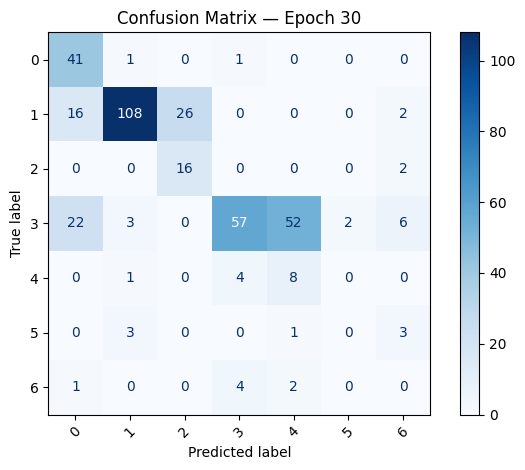

[31/300] Train Loss: 1.0408 | Train Acc: 0.5947 | Val Loss: 1.1661 | Val Acc: 0.6052 | Val Macro F1: 0.3983 | Val PR AUC: 0.5477


[32/300] Train Loss: 1.0423 | Train Acc: 0.6005 | Val Loss: 1.1621 | Val Acc: 0.6052 | Val Macro F1: 0.3982 | Val PR AUC: 0.5474
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[33/300] Train Loss: 1.0117 | Train Acc: 0.6121 | Val Loss: 1.1668 | Val Acc: 0.6026 | Val Macro F1: 0.3981 | Val PR AUC: 0.5534


[34/300] Train Loss: 1.0365 | Train Acc: 0.5843 | Val Loss: 1.1615 | Val Acc: 0.6052 | Val Macro F1: 0.3983 | Val PR AUC: 0.5502
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[35/300] Train Loss: 1.0401 | Train Acc: 0.6114 | Val Loss: 1.1617 | Val Acc: 0.6182 | Val Macro F1: 0.4052 | Val PR AUC: 0.5517


[36/300] Train Loss: 1.0167 | Train Acc: 0.5990 | Val Loss: 1.1661 | Val Acc: 0.5870 | Val Macro F1: 0.3900 | Val PR AUC: 0.5529


[37/300] Train Loss: 1.0118 | Train Acc: 0.6034 | Val Loss: 1.1631 | Val Acc: 0.6026 | Val Macro F1: 0.4011 | Val PR AUC: 0.5538


[38/300] Train Loss: 1.0009 | Train Acc: 0.5984 | Val Loss: 1.1576 | Val Acc: 0.6156 | Val Macro F1: 0.4065 | Val PR AUC: 0.5535
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[39/300] Train Loss: 0.9815 | Train Acc: 0.6049 | Val Loss: 1.1527 | Val Acc: 0.6078 | Val Macro F1: 0.4008 | Val PR AUC: 0.5509
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[40/300] Train Loss: 0.9909 | Train Acc: 0.5966 | Val Loss: 1.1590 | Val Acc: 0.6104 | Val Macro F1: 0.4290 | Val PR AUC: 0.5440


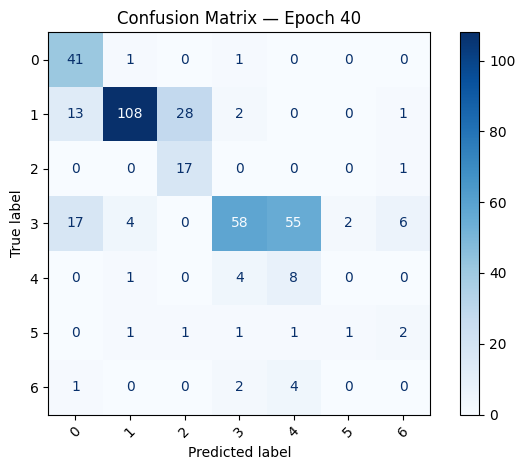

[41/300] Train Loss: 0.9821 | Train Acc: 0.5850 | Val Loss: 1.1592 | Val Acc: 0.6130 | Val Macro F1: 0.4334 | Val PR AUC: 0.5477


[42/300] Train Loss: 0.9764 | Train Acc: 0.6192 | Val Loss: 1.1524 | Val Acc: 0.6182 | Val Macro F1: 0.4115 | Val PR AUC: 0.5378
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[43/300] Train Loss: 0.9705 | Train Acc: 0.6045 | Val Loss: 1.1544 | Val Acc: 0.6130 | Val Macro F1: 0.4075 | Val PR AUC: 0.5411


[44/300] Train Loss: 0.9610 | Train Acc: 0.6171 | Val Loss: 1.1579 | Val Acc: 0.6052 | Val Macro F1: 0.4040 | Val PR AUC: 0.5524


[45/300] Train Loss: 0.9730 | Train Acc: 0.5899 | Val Loss: 1.1579 | Val Acc: 0.6104 | Val Macro F1: 0.4058 | Val PR AUC: 0.5418


[46/300] Train Loss: 0.9533 | Train Acc: 0.5982 | Val Loss: 1.1522 | Val Acc: 0.6104 | Val Macro F1: 0.4064 | Val PR AUC: 0.5388
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[47/300] Train Loss: 0.9512 | Train Acc: 0.6323 | Val Loss: 1.1560 | Val Acc: 0.6260 | Val Macro F1: 0.4144 | Val PR AUC: 0.5470


[48/300] Train Loss: 0.9275 | Train Acc: 0.6278 | Val Loss: 1.1651 | Val Acc: 0.6104 | Val Macro F1: 0.4064 | Val PR AUC: 0.5384


[49/300] Train Loss: 0.9615 | Train Acc: 0.6036 | Val Loss: 1.1586 | Val Acc: 0.6286 | Val Macro F1: 0.4124 | Val PR AUC: 0.5420


[50/300] Train Loss: 0.9506 | Train Acc: 0.6125 | Val Loss: 1.1587 | Val Acc: 0.6234 | Val Macro F1: 0.4367 | Val PR AUC: 0.5407


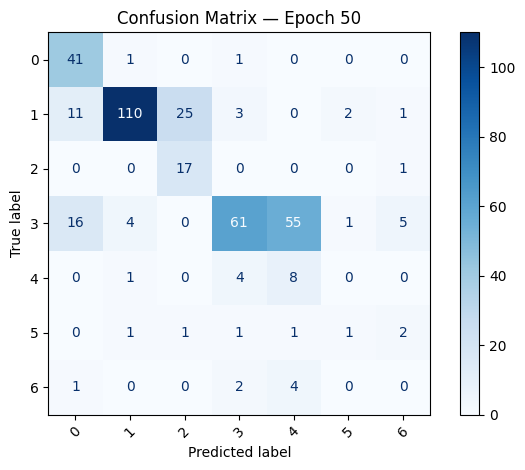

[51/300] Train Loss: 0.9256 | Train Acc: 0.6294 | Val Loss: 1.1435 | Val Acc: 0.6078 | Val Macro F1: 0.4297 | Val PR AUC: 0.5423
Saving best val_acc model weights to /content/drive/MyDrive/stocks/duet/duet_class/weights/best_val_acc_weights_002.pt


[52/300] Train Loss: 0.9302 | Train Acc: 0.5972 | Val Loss: 1.1438 | Val Acc: 0.6234 | Val Macro F1: 0.4364 | Val PR AUC: 0.5403


[53/300] Train Loss: 0.9508 | Train Acc: 0.6008 | Val Loss: 1.1502 | Val Acc: 0.6208 | Val Macro F1: 0.4382 | Val PR AUC: 0.5435


[54/300] Train Loss: 0.9299 | Train Acc: 0.6066 | Val Loss: 1.1618 | Val Acc: 0.6104 | Val Macro F1: 0.4334 | Val PR AUC: 0.5423


[55/300] Train Loss: 0.9125 | Train Acc: 0.6110 | Val Loss: 1.1635 | Val Acc: 0.6339 | Val Macro F1: 0.4404 | Val PR AUC: 0.5410


[56/300] Train Loss: 0.9222 | Train Acc: 0.6172 | Val Loss: 1.1496 | Val Acc: 0.6339 | Val Macro F1: 0.4408 | Val PR AUC: 0.5391


[57/300] Train Loss: 0.9228 | Train Acc: 0.6186 | Val Loss: 1.1680 | Val Acc: 0.6156 | Val Macro F1: 0.4333 | Val PR AUC: 0.5401


[58/300] Train Loss: 0.9105 | Train Acc: 0.6215 | Val Loss: 1.1661 | Val Acc: 0.6260 | Val Macro F1: 0.4398 | Val PR AUC: 0.5443


[59/300] Train Loss: 0.9036 | Train Acc: 0.6224 | Val Loss: 1.1659 | Val Acc: 0.6208 | Val Macro F1: 0.4395 | Val PR AUC: 0.5471


[60/300] Train Loss: 0.9002 | Train Acc: 0.6239 | Val Loss: 1.1672 | Val Acc: 0.6260 | Val Macro F1: 0.4387 | Val PR AUC: 0.5454


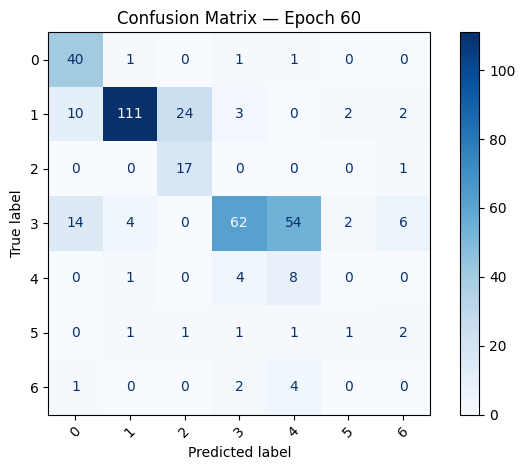

[61/300] Train Loss: 0.9131 | Train Acc: 0.6203 | Val Loss: 1.1664 | Val Acc: 0.6339 | Val Macro F1: 0.4411 | Val PR AUC: 0.5444


[62/300] Train Loss: 0.8766 | Train Acc: 0.6159 | Val Loss: 1.1621 | Val Acc: 0.6208 | Val Macro F1: 0.4383 | Val PR AUC: 0.5523


[63/300] Train Loss: 0.8988 | Train Acc: 0.6198 | Val Loss: 1.1624 | Val Acc: 0.6547 | Val Macro F1: 0.4517 | Val PR AUC: 0.5443


[64/300] Train Loss: 0.8832 | Train Acc: 0.6212 | Val Loss: 1.1614 | Val Acc: 0.6312 | Val Macro F1: 0.4415 | Val PR AUC: 0.5483


[65/300] Train Loss: 0.8968 | Train Acc: 0.6334 | Val Loss: 1.1597 | Val Acc: 0.6260 | Val Macro F1: 0.4389 | Val PR AUC: 0.5530


[66/300] Train Loss: 0.8922 | Train Acc: 0.6303 | Val Loss: 1.1610 | Val Acc: 0.6469 | Val Macro F1: 0.4509 | Val PR AUC: 0.5539


[67/300] Train Loss: 0.8878 | Train Acc: 0.6179 | Val Loss: 1.1655 | Val Acc: 0.6286 | Val Macro F1: 0.4431 | Val PR AUC: 0.5552


[68/300] Train Loss: 0.8608 | Train Acc: 0.6457 | Val Loss: 1.1792 | Val Acc: 0.6234 | Val Macro F1: 0.4394 | Val PR AUC: 0.5538


[69/300] Train Loss: 0.8871 | Train Acc: 0.6342 | Val Loss: 1.1712 | Val Acc: 0.6391 | Val Macro F1: 0.4441 | Val PR AUC: 0.5557


[70/300] Train Loss: 0.8799 | Train Acc: 0.6312 | Val Loss: 1.1688 | Val Acc: 0.6469 | Val Macro F1: 0.4487 | Val PR AUC: 0.5546


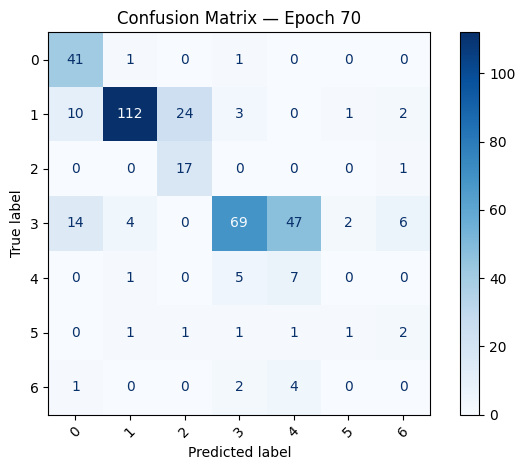

[71/300] Train Loss: 0.8882 | Train Acc: 0.6246 | Val Loss: 1.1595 | Val Acc: 0.6365 | Val Macro F1: 0.4452 | Val PR AUC: 0.5578


[72/300] Train Loss: 0.8581 | Train Acc: 0.6296 | Val Loss: 1.1857 | Val Acc: 0.6078 | Val Macro F1: 0.4322 | Val PR AUC: 0.5534


[73/300] Train Loss: 0.8653 | Train Acc: 0.6343 | Val Loss: 1.1771 | Val Acc: 0.6260 | Val Macro F1: 0.4411 | Val PR AUC: 0.5495


[74/300] Train Loss: 0.8616 | Train Acc: 0.6225 | Val Loss: 1.1774 | Val Acc: 0.6365 | Val Macro F1: 0.4468 | Val PR AUC: 0.5544


[75/300] Train Loss: 0.8584 | Train Acc: 0.6280 | Val Loss: 1.1689 | Val Acc: 0.6417 | Val Macro F1: 0.4227 | Val PR AUC: 0.5483


[76/300] Train Loss: 0.8490 | Train Acc: 0.6278 | Val Loss: 1.1669 | Val Acc: 0.6627 | Val Macro F1: 0.4347 | Val PR AUC: 0.5486


[77/300] Train Loss: 0.8647 | Train Acc: 0.6506 | Val Loss: 1.1824 | Val Acc: 0.6495 | Val Macro F1: 0.4510 | Val PR AUC: 0.5507


[78/300] Train Loss: 0.8438 | Train Acc: 0.6477 | Val Loss: 1.1878 | Val Acc: 0.6417 | Val Macro F1: 0.4487 | Val PR AUC: 0.5501


[79/300] Train Loss: 0.8630 | Train Acc: 0.6121 | Val Loss: 1.1866 | Val Acc: 0.6443 | Val Macro F1: 0.4514 | Val PR AUC: 0.5489


[80/300] Train Loss: 0.8530 | Train Acc: 0.6377 | Val Loss: 1.1855 | Val Acc: 0.6549 | Val Macro F1: 0.4602 | Val PR AUC: 0.5467


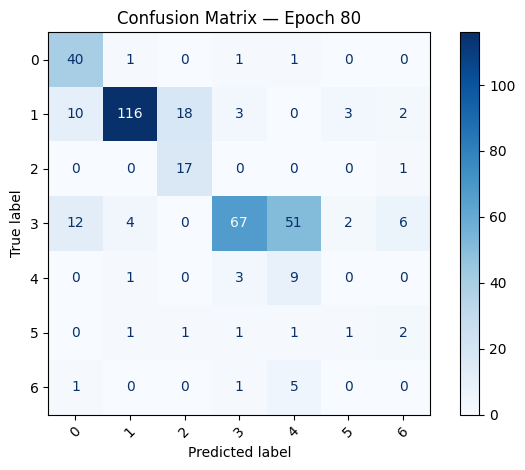

[81/300] Train Loss: 0.8348 | Train Acc: 0.6415 | Val Loss: 1.1854 | Val Acc: 0.6469 | Val Macro F1: 0.4489 | Val PR AUC: 0.5471


[82/300] Train Loss: 0.8403 | Train Acc: 0.6480 | Val Loss: 1.2031 | Val Acc: 0.6521 | Val Macro F1: 0.4521 | Val PR AUC: 0.5422


[83/300] Train Loss: 0.8305 | Train Acc: 0.6377 | Val Loss: 1.2056 | Val Acc: 0.6417 | Val Macro F1: 0.4497 | Val PR AUC: 0.5460


[84/300] Train Loss: 0.8352 | Train Acc: 0.6463 | Val Loss: 1.2096 | Val Acc: 0.6312 | Val Macro F1: 0.4431 | Val PR AUC: 0.5506


[85/300] Train Loss: 0.8208 | Train Acc: 0.6284 | Val Loss: 1.2066 | Val Acc: 0.6443 | Val Macro F1: 0.4504 | Val PR AUC: 0.5468


[86/300] Train Loss: 0.8301 | Train Acc: 0.6403 | Val Loss: 1.1920 | Val Acc: 0.6469 | Val Macro F1: 0.4531 | Val PR AUC: 0.5494


[87/300] Train Loss: 0.8194 | Train Acc: 0.6502 | Val Loss: 1.2158 | Val Acc: 0.6470 | Val Macro F1: 0.4557 | Val PR AUC: 0.5489


[88/300] Train Loss: 0.8288 | Train Acc: 0.6362 | Val Loss: 1.2069 | Val Acc: 0.6521 | Val Macro F1: 0.4550 | Val PR AUC: 0.5472


[89/300] Train Loss: 0.8093 | Train Acc: 0.6424 | Val Loss: 1.2081 | Val Acc: 0.6443 | Val Macro F1: 0.4496 | Val PR AUC: 0.5438


[90/300] Train Loss: 0.8129 | Train Acc: 0.6282 | Val Loss: 1.2119 | Val Acc: 0.6469 | Val Macro F1: 0.4496 | Val PR AUC: 0.5496


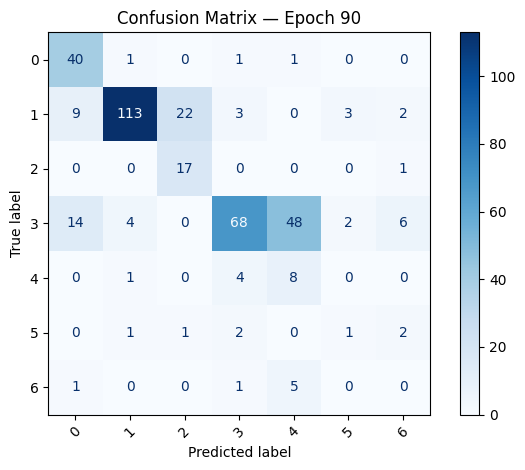

[91/300] Train Loss: 0.8055 | Train Acc: 0.6434 | Val Loss: 1.2026 | Val Acc: 0.6523 | Val Macro F1: 0.4724 | Val PR AUC: 0.5513


[92/300] Train Loss: 0.8166 | Train Acc: 0.6525 | Val Loss: 1.2215 | Val Acc: 0.6443 | Val Macro F1: 0.4537 | Val PR AUC: 0.5524


[93/300] Train Loss: 0.7895 | Train Acc: 0.6385 | Val Loss: 1.2207 | Val Acc: 0.6443 | Val Macro F1: 0.4554 | Val PR AUC: 0.5428


[94/300] Train Loss: 0.7845 | Train Acc: 0.6290 | Val Loss: 1.2324 | Val Acc: 0.6443 | Val Macro F1: 0.4555 | Val PR AUC: 0.5461


[95/300] Train Loss: 0.7964 | Train Acc: 0.6474 | Val Loss: 1.2176 | Val Acc: 0.6679 | Val Macro F1: 0.4634 | Val PR AUC: 0.5480


In [ ]:
# --- 4. Создание DataLoader'ов ---
train_dataset = TensorDataset(
    torch.tensor(x_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)
val_dataset = TensorDataset(
    torch.tensor(x_val, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(x_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size)

# --- 6. Инициализация модели ---
model = DUETModel(config).to(device)

# --- 7. Обучение модели ---
trained_model = train.train_model(
    model,
    config,
    train_loader,
    val_loader,
    device=device,
    class_weights = class_weights
)

In [ ]:
# Загрузка весов

model.load_state_dict(torch.load(config.checkpoint_best)) # загрузка лучших весов
# model.load_state_dict(torch.load(config.checkpoint_final)) # загрузка финальных весов
model.eval()

In [ ]:
# Оценка модели на тест данных
from pipeline.visualiser import plot_pr_auc, plot_roc_auc

y_true, y_pred, y_prob = evaluate.evaluate_model(model, val_loader, return_proba=True, device="cuda") # test_loader

# Подсчёт метрик
metrics = evaluate.compute_metrics(y_true, y_pred)
print("\nMetrics:")
for metric, value in metrics.items():
    print(f"{metric.upper()}: {value:.2f}")


# Матрица ошибок
evaluate.plot_confusion_matrix(y_true, y_pred)
plot_pr_auc(y_true, y_prob, n_classes=config.num_classes)
plot_roc_auc(y_true, y_prob, n_classes=config.num_classes)

# Примеры предсказаний
evaluate.plot_classification_examples(y_true, y_pred, n=10)